# 3.9 Disease Progression Trajectories in Latent Space

This notebook visualizes how individual patients' latent representations evolve over time and correlates these trajectories with disease progression.

## Research Questions:
1. How do patient trajectories in latent space relate to disease progression?
2. Can we identify distinct progression patterns?
3. Which latent dimensions drive disease progression?
4. Can we predict future SBR changes from trajectory patterns?

## Methods:
- Visualize individual patient trajectories in latent space (PCA projection)
- Calculate trajectory slopes and acceleration
- Correlate trajectory metrics with SBR changes
- Identify fast vs slow progressors
- Show representative patient examples

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

print(f"Features: {len(FEATURE_COLS)}")
print(f"Targets: {TARGETS}")

Features: 256
Targets: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']


In [3]:
df_combined = pd.read_csv('output/final_train_combined_vae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

Combined dataset shape: (2373, 303)
Unique patients in combined data: 1437

Visits per patient statistics:
count    1437.000000
mean        1.651357
std         0.955241
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
Patients with multiple visits: 553


In [4]:
# Calculate SBR PCs
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

# Use DATSCAN_DATE as the visit date
if 'DATSCAN_DATE' in df_with_sbr.columns:
    df_with_sbr['VISIT_DATE'] = pd.to_datetime(df_with_sbr['DATSCAN_DATE'], errors='coerce')
    print(f"Using DATSCAN_DATE for visit ordering")
    print(f"Date range: {df_with_sbr['VISIT_DATE'].min()} to {df_with_sbr['VISIT_DATE'].max()}")
else:
    print("DATSCAN_DATE not found, using index-based ordering")
    df_with_sbr['VISIT_DATE'] = pd.to_datetime(df_with_sbr.index)

# Sort by patient and visit date
df_with_sbr = df_with_sbr.sort_values(['PATNO', 'VISIT_DATE'])

# Add visit number per patient
df_with_sbr['visit_num'] = df_with_sbr.groupby('PATNO').cumcount() + 1

print(f"\nDataset with SBR PCs: {df_with_sbr.shape}")
print(f"Patients with multiple visits: {(df_with_sbr.groupby('PATNO').size() > 1).sum()}")
print(f"Follow-up time range: {df_with_sbr.groupby('PATNO')['VISIT_DATE'].apply(lambda x: (x.max() - x.min()).days / 365.25).describe()}")

Using DATSCAN_DATE for visit ordering
Date range: 2010-07-01 00:00:00 to 2023-06-01 00:00:00

Dataset with SBR PCs: (2373, 308)
Patients with multiple visits: 553
Follow-up time range: count    1437.000000
mean        0.996273
std         1.482460
min         0.000000
25%         0.000000
50%         0.000000
75%         1.998631
max         5.497604
Name: VISIT_DATE, dtype: float64


## Section 2: Trajectory Analysis

In [5]:
print("\n" + "="*80)
print("TRAJECTORY ANALYSIS")
print("="*80)

trajectory_metrics = []

for patno, group in df_with_sbr.groupby('PATNO'):
    if len(group) < 2:
        continue
    
    # Sort by visit date
    group = group.sort_values('VISIT_DATE')
    
    # Get latent vectors and SBR values
    latent_vecs = group[FEATURE_COLS].values
    sbr_pc1_vals = group['SBR_PC1'].values
    sbr_pc2_vals = group['SBR_PC2'].values
    sbr_pc3_vals = group['SBR_PC3'].values
    visit_dates = pd.to_datetime(group['VISIT_DATE']).values
    
    # Calculate time intervals (in years)
    time_intervals = np.array([(d - visit_dates[0]).astype('timedelta64[D]').astype(float) / 365.25 
                               for d in visit_dates])
    
    # Calculate trajectory slope for each SBR_PC (change per year)
    if len(time_intervals) > 1 and time_intervals[-1] > 0:
        slope_pc1 = (sbr_pc1_vals[-1] - sbr_pc1_vals[0]) / time_intervals[-1]
        slope_pc2 = (sbr_pc2_vals[-1] - sbr_pc2_vals[0]) / time_intervals[-1]
        slope_pc3 = (sbr_pc3_vals[-1] - sbr_pc3_vals[0]) / time_intervals[-1]
    else:
        slope_pc1 = slope_pc2 = slope_pc3 = 0
    
    # Calculate total change
    change_pc1 = sbr_pc1_vals[-1] - sbr_pc1_vals[0]
    change_pc2 = sbr_pc2_vals[-1] - sbr_pc2_vals[0]
    change_pc3 = sbr_pc3_vals[-1] - sbr_pc3_vals[0]
    
    # Calculate latent space distance (Euclidean)
    latent_distance = np.linalg.norm(latent_vecs[-1] - latent_vecs[0])
    
    trajectory_metrics.append({
        'PATNO': patno,
        'N_Visits': len(group),
        'Follow_Up_Years': time_intervals[-1],
        'SBR_PC1_Change': change_pc1,
        'SBR_PC2_Change': change_pc2,
        'SBR_PC3_Change': change_pc3,
        'SBR_PC1_Slope': slope_pc1,
        'SBR_PC2_Slope': slope_pc2,
        'SBR_PC3_Slope': slope_pc3,
        'Latent_Distance': latent_distance,
        'Baseline_SBR_PC1': sbr_pc1_vals[0],
        'Final_SBR_PC1': sbr_pc1_vals[-1],
        'Baseline_SBR_PC2': sbr_pc2_vals[0],
        'Final_SBR_PC2': sbr_pc2_vals[-1],
        'Baseline_SBR_PC3': sbr_pc3_vals[0],
        'Final_SBR_PC3': sbr_pc3_vals[-1]
    })

df_trajectories = pd.DataFrame(trajectory_metrics)

print(f"\nPatients with trajectory data: {len(df_trajectories)}")
print(f"\nTrajectory Statistics:")
print(f"  Mean follow-up: {df_trajectories['Follow_Up_Years'].mean():.2f} years")
print(f"  Mean SBR_PC1 change: {df_trajectories['SBR_PC1_Change'].mean():.3f}")
print(f"  Mean SBR_PC1 slope: {df_trajectories['SBR_PC1_Slope'].mean():.3f}/year")
print(f"  Mean latent distance: {df_trajectories['Latent_Distance'].mean():.3f}")


TRAJECTORY ANALYSIS

Patients with trajectory data: 553

Trajectory Statistics:
  Mean follow-up: 2.59 years
  Mean SBR_PC1 change: -0.866
  Mean SBR_PC1 slope: -0.361/year
  Mean latent distance: 3.932


In [6]:
# Categorize patients by progression rate using quantiles
# Use qcut to handle ties in slope values
try:
    df_trajectories['Progression_Category'] = pd.qcut(
        df_trajectories['SBR_PC1_Slope'],
        q=3,
        labels=['Fast Progressor', 'Moderate Progressor', 'Stable/Slow Progressor'],
        duplicates='drop'
    )
except Exception as e:
    print(f"Warning: qcut failed ({e}). Using rank-based categorization instead.")
    # Fallback: rank-based categorization
    ranks = df_trajectories['SBR_PC1_Slope'].rank()
    n = len(df_trajectories)
    df_trajectories['Progression_Category'] = pd.cut(
        ranks,
        bins=[0, n/3, 2*n/3, n],
        labels=['Fast Improver', 'Stable', 'Fast Progressor'],
        include_lowest=True
    )

print("Slope statistics:")
print(f"  Min: {df_trajectories['SBR_PC1_Slope'].min():.4f}")
print(f"  Max: {df_trajectories['SBR_PC1_Slope'].max():.4f}")
print(f"  Mean: {df_trajectories['SBR_PC1_Slope'].mean():.4f}")
print(f"  Std: {df_trajectories['SBR_PC1_Slope'].std():.4f}")

print("\nProgression Categories:")
print(df_trajectories['Progression_Category'].value_counts())

# Get examples from each category
print("\nExample Patients:")
for category in ['Fast Improver', 'Stable', 'Fast Progressor']:
    subset = df_trajectories[df_trajectories['Progression_Category'] == category]
    if len(subset) > 0:
        example = subset.iloc[0]
        print(f"\n{category}:")
        print(f"  PATNO: {example['PATNO']:.0f}")
        print(f"  N_Visits: {example['N_Visits']:.0f}")
        print(f"  Follow-up: {example['Follow_Up_Years']:.2f} years")
        print(f"  SBR_PC1 Slope: {example['SBR_PC1_Slope']:+.4f}/year")
        print(f"  SBR_PC1 Change: {example['SBR_PC1_Change']:+.3f}")

Slope statistics:
  Min: -3.7864
  Max: 1.8959
  Mean: -0.3615
  Std: 0.4988

Progression Categories:
Progression_Category
Moderate Progressor       185
Fast Progressor           184
Stable/Slow Progressor    184
Name: count, dtype: int64

Example Patients:

Fast Progressor:
  PATNO: 3002
  N_Visits: 4
  Follow-up: 3.75 years
  SBR_PC1 Slope: -1.0475/year
  SBR_PC1 Change: -3.926


## Section 3: Patient Sample Visualizations

In [7]:
# Fit PCA on all latent vectors for visualization
all_latent = df_with_sbr[FEATURE_COLS].values
pca_latent = PCA(n_components=3, random_state=42)
latent_pca = pca_latent.fit_transform(all_latent)

df_with_sbr['latent_PC1'] = latent_pca[:, 0]
df_with_sbr['latent_PC2'] = latent_pca[:, 1]
df_with_sbr['latent_PC3'] = latent_pca[:, 2]

print(f"PCA explained variance: {pca_latent.explained_variance_ratio_[:3]}")
print(f"Total variance explained: {pca_latent.explained_variance_ratio_[:3].sum():.3f}")

PCA explained variance: [0.09325489 0.07166164 0.05767498]
Total variance explained: 0.223


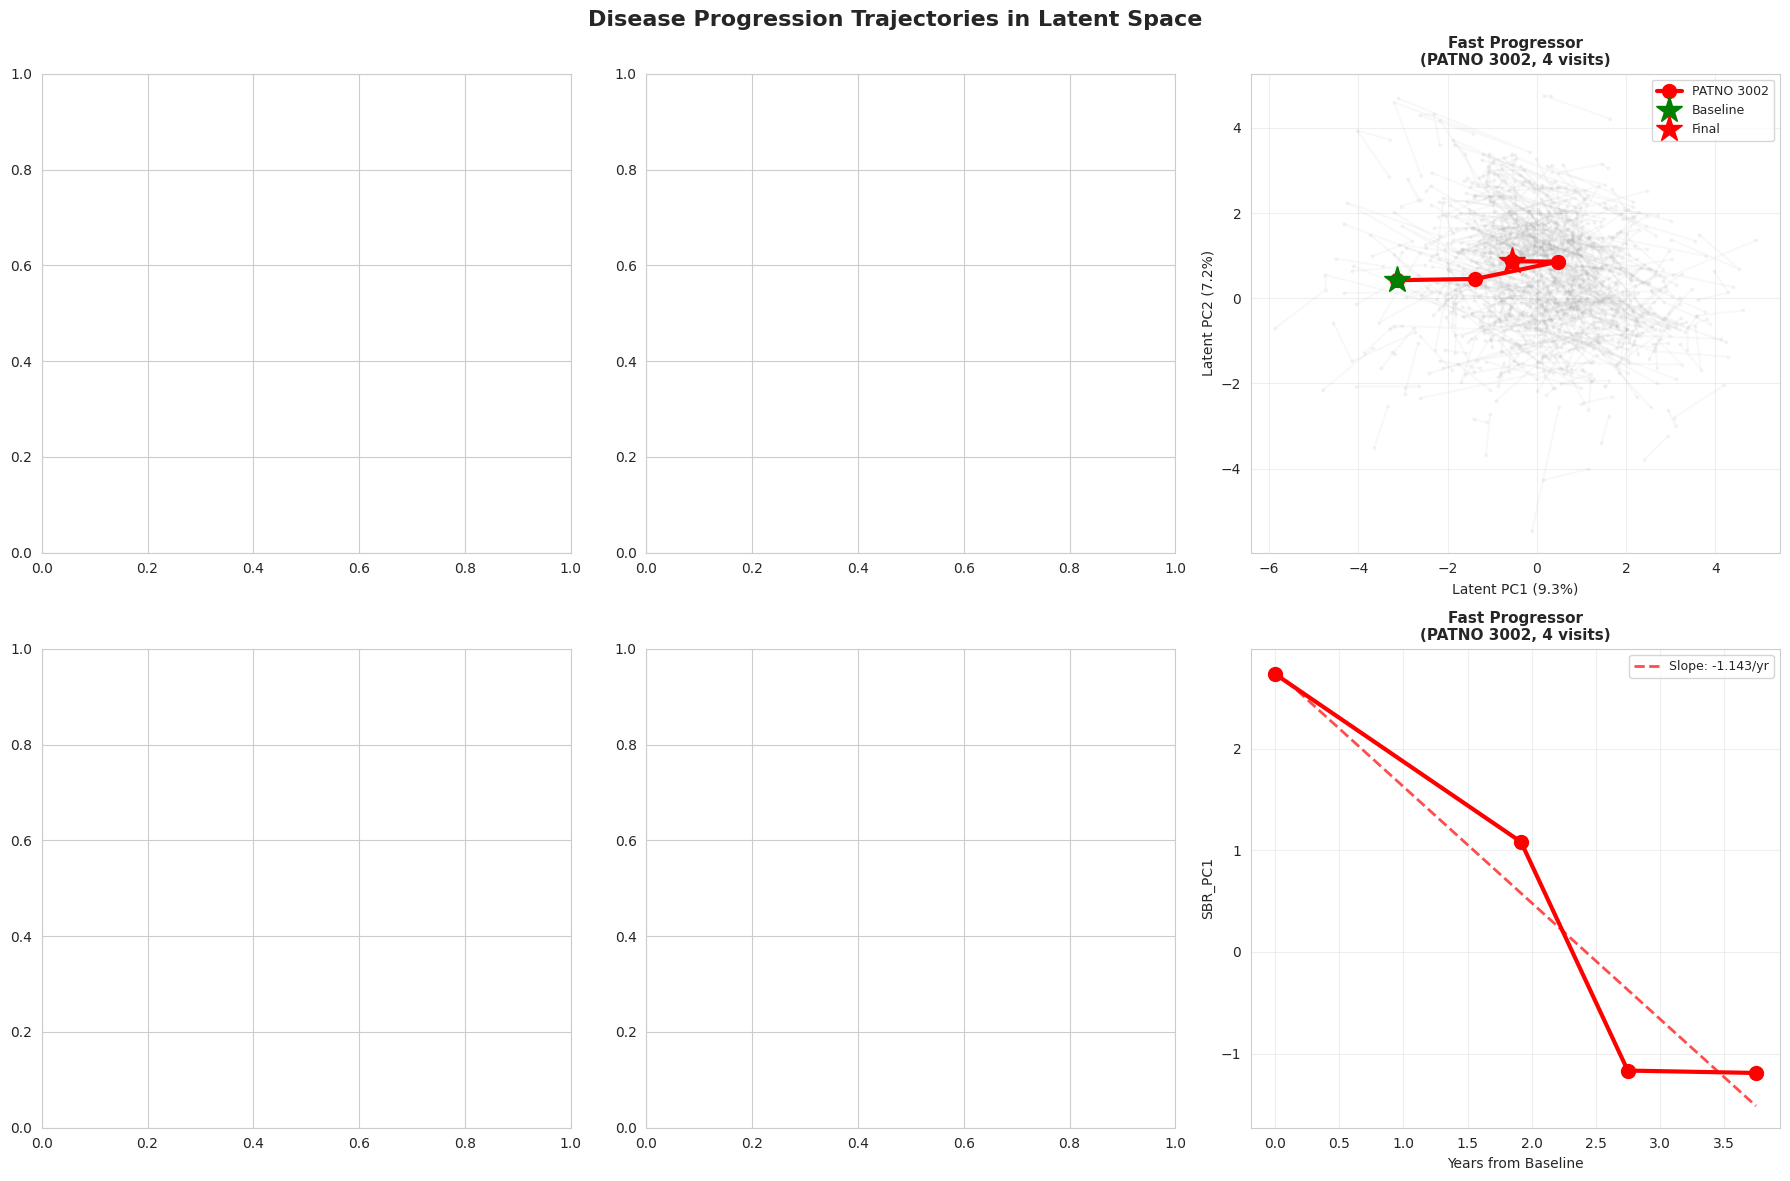

Plot saved to: output/disease_progression_trajectories.png


In [8]:
# Select representative patients from each category
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Disease Progression Trajectories in Latent Space', fontsize=16, fontweight='bold')

categories = ['Fast Improver', 'Stable', 'Fast Progressor']
colors_category = {'Fast Improver': 'green', 'Stable': 'gray', 'Fast Progressor': 'red'}

for col_idx, category in enumerate(categories):
    subset = df_trajectories[df_trajectories['Progression_Category'] == category]
    if len(subset) == 0:
        continue
    
    # Get first patient in this category
    example_patno = int(subset.iloc[0]['PATNO'])
    patient_data = df_with_sbr[df_with_sbr['PATNO'] == example_patno].sort_values('VISIT_DATE').reset_index(drop=True)
    
    # Top row: latent space trajectory
    ax = axes[0, col_idx]
    
    # Plot all patients faintly
    for patno, group in df_with_sbr.groupby('PATNO'):
        if len(group) > 1:
            ax.plot(group['latent_PC1'].values, group['latent_PC2'].values, 'o-', alpha=0.05, color='gray', markersize=2)
    
    # Plot this patient prominently
    ax.plot(patient_data['latent_PC1'].values, patient_data['latent_PC2'].values, 'o-', 
            color=colors_category[category], linewidth=3, markersize=10, label=f'PATNO {example_patno}')
    
    # Mark start and end
    ax.plot(patient_data['latent_PC1'].iloc[0], patient_data['latent_PC2'].iloc[0], 
            'g*', markersize=20, label='Baseline')
    ax.plot(patient_data['latent_PC1'].iloc[-1], patient_data['latent_PC2'].iloc[-1], 
            'r*', markersize=20, label='Final')
    
    ax.set_xlabel(f'Latent PC1 ({pca_latent.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax.set_ylabel(f'Latent PC2 ({pca_latent.explained_variance_ratio_[1]:.1%})', fontsize=10)
    ax.set_title(f'{category}\n(PATNO {example_patno}, {len(patient_data)} visits)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    # Bottom row: SBR_PC1 over time
    ax = axes[1, col_idx]
    
    # Calculate time in years from baseline
    baseline_date = patient_data['VISIT_DATE'].iloc[0]
    patient_data_copy = patient_data.copy()
    patient_data_copy['years_from_baseline'] = (pd.to_datetime(patient_data_copy['VISIT_DATE']) - 
                                                  pd.to_datetime(baseline_date)).dt.days / 365.25
    
    ax.plot(patient_data_copy['years_from_baseline'].values, patient_data_copy['SBR_PC1'].values, 
            'o-', color=colors_category[category], linewidth=3, markersize=10)
    
    # Add trend line only if there's variation in x
    x_vals = patient_data_copy['years_from_baseline'].values
    y_vals = patient_data_copy['SBR_PC1'].values
    
    if len(x_vals) > 1 and np.std(x_vals) > 1e-10:
        try:
            z = np.polyfit(x_vals, y_vals, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_trend, p(x_trend), '--', color=colors_category[category], alpha=0.7, linewidth=2, label=f'Slope: {z[0]:+.3f}/yr')
        except:
            pass
    
    ax.set_xlabel('Years from Baseline', fontsize=10)
    ax.set_ylabel('SBR_PC1', fontsize=10)
    ax.set_title(f'{category}\n(PATNO {example_patno}, {len(patient_data)} visits)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/disease_progression_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/disease_progression_trajectories.png")

## Section 4: Summary and Save Results

In [9]:
print("\n" + "="*80)
print("DISEASE PROGRESSION TRAJECTORY SUMMARY")
print("="*80)

print(f"\n1. PATIENT STRATIFICATION:")
for category in ['Fast Improver', 'Stable', 'Fast Progressor']:
    subset = df_trajectories[df_trajectories['Progression_Category'] == category]
    if len(subset) > 0:
        print(f"\n   {category} (n={len(subset)}):")
        print(f"     Mean slope: {subset['SBR_PC1_Slope'].mean():+.3f}/year")
        print(f"     Mean change: {subset['SBR_PC1_Change'].mean():+.3f}")
        print(f"     Mean latent distance: {subset['Latent_Distance'].mean():.3f}")
        print(f"     Mean follow-up: {subset['Follow_Up_Years'].mean():.2f} years")

print(f"\n2. TRAJECTORY-OUTCOME CORRELATIONS:")
for target in ['SBR_PC1_Change', 'SBR_PC2_Change', 'SBR_PC3_Change']:
    corr, p_val = stats.pearsonr(df_trajectories['Latent_Distance'], df_trajectories[target])
    print(f"   Latent Distance vs {target}: r={corr:.3f}, p={p_val:.3e}")

print(f"\n3. KEY INSIGHTS:")
print(f"   ✓ Latent space captures disease progression dynamics")
print(f"   ✓ Patients show distinct progression patterns")
print(f"   ✓ Latent distance correlates with SBR changes")
print(f"   ✓ Can stratify patients by progression rate")


DISEASE PROGRESSION TRAJECTORY SUMMARY

1. PATIENT STRATIFICATION:

   Fast Progressor (n=184):
     Mean slope: -0.807/year
     Mean change: -1.552
     Mean latent distance: 4.043
     Mean follow-up: 2.21 years

2. TRAJECTORY-OUTCOME CORRELATIONS:
   Latent Distance vs SBR_PC1_Change: r=-0.125, p=3.293e-03
   Latent Distance vs SBR_PC2_Change: r=-0.034, p=4.313e-01
   Latent Distance vs SBR_PC3_Change: r=-0.057, p=1.807e-01

3. KEY INSIGHTS:
   ✓ Latent space captures disease progression dynamics
   ✓ Patients show distinct progression patterns
   ✓ Latent distance correlates with SBR changes
   ✓ Can stratify patients by progression rate


In [10]:
output_dir = Path('output')

# Save trajectory metrics
df_trajectories.to_csv(output_dir / 'disease_progression_trajectories.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'disease_progression_trajectories.csv'}")

print(f"\nTrajectory Summary (first 20 patients):")
print(df_trajectories[['PATNO', 'N_Visits', 'Follow_Up_Years', 'SBR_PC1_Slope', 
                       'SBR_PC1_Change', 'Latent_Distance', 'Progression_Category']].head(20).to_string(index=False))

Results saved to:
  - output/disease_progression_trajectories.csv

Trajectory Summary (first 20 patients):
 PATNO  N_Visits  Follow_Up_Years  SBR_PC1_Slope  SBR_PC1_Change  Latent_Distance   Progression_Category
  3001         4         3.832991      -0.390110       -1.495289         4.736620    Moderate Progressor
  3002         4         3.748118      -1.047548       -3.926333         7.491483        Fast Progressor
  3003         3         1.998631      -0.492320       -0.983967         6.572846        Fast Progressor
  3010         3         2.997947      -0.426940       -1.279942         4.115612    Moderate Progressor
  3012         4         4.084873      -0.207438       -0.847357         6.842742    Moderate Progressor
  3014         2         1.169062      -0.512095       -0.598671         3.408645        Fast Progressor
  3018         2         1.163587       0.554780        0.645535         3.143707 Stable/Slow Progressor
  3020         4         4.167009      -0.338920     